In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

sns.set(style="whitegrid")
df = pd.read_csv("personality.csv")

Personality psychology classifies individuals broadly as introverts or extroverts, based on behavioral tendencies such as socialization patterns, energy levels, and interaction preferences.
In this project, we build a machine learning model to predict personality type based on behavioral and lifestyle features.

Dataset includes features such as:
	•	Time spent alone
	•	Social event attendance
	•	Friends circle size
	•	Online posting frequency
	•	Stage fear
	•	Energy after socializing

This project demonstrates the entire data science lifecycle:
	•	Exploratory Data Analysis (EDA)
	•	Data cleaning and preprocessing
	•	Model training and evaluation
	•	Model comparison
	•	Feature importance analysis
	•	Final conclusions and insights

In [3]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


No missing values
Duplicates removed

In [3]:
df.isnull().sum()
df = df.drop_duplicates()

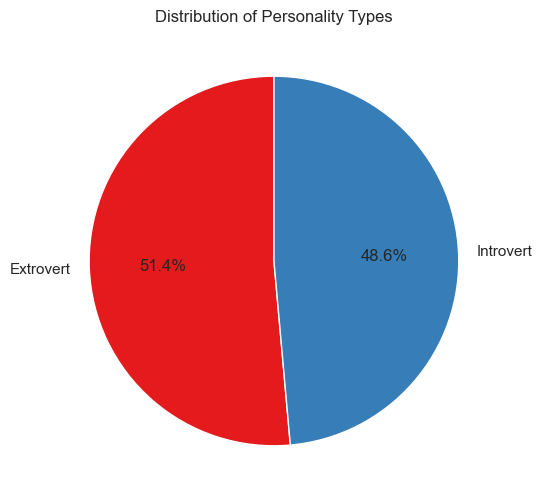

In [4]:
pers_count = df["Personality"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    pers_count,
    labels=pers_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1')
)
plt.title("Distribution of Personality Types")
plt.show()
#The dataset is relatively balanced, with extroverts slightly overrepresented.

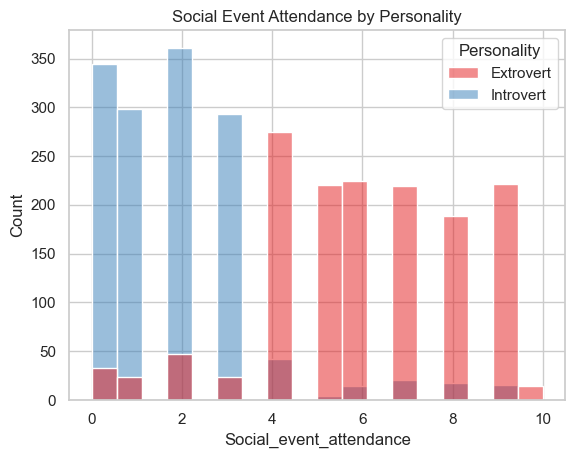

In [5]:
sns.histplot(
    data=df,
    x='Social_event_attendance',
    hue="Personality",
    palette="Set1",
)
plt.title("Social Event Attendance by Personality")
plt.show()
#Introverts mostly attend 0–3 events per month, while extroverts show higher attendance (4–10).
#Clear behavioral separation appears.

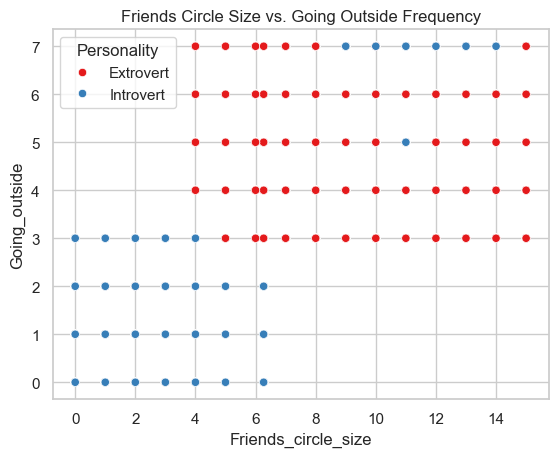

In [6]:
sns.scatterplot(
    data=df,
    x='Friends_circle_size',
    y='Going_outside',
    hue='Personality',
    palette='Set1'
)
plt.title("Friends Circle Size vs. Going Outside Frequency")
plt.show()
#Extroverts cluster toward higher social activity and more friends.
#Introverts cluster toward lower values for both.

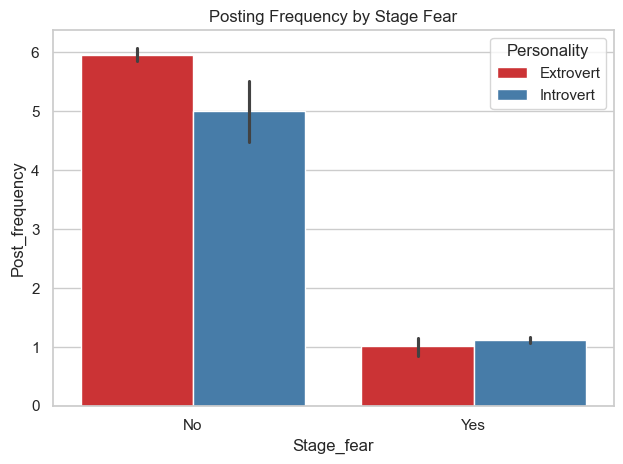

In [7]:
sns.barplot(
    data=df,
    x='Stage_fear',
    y='Post_frequency',
    hue='Personality',
    palette='Set1'
)
plt.title("Posting Frequency by Stage Fear")
plt.tight_layout()
plt.show()
#People without stage fear post more frequently online.
#However, many introverts also post regularly, showing that introversion ≠ shyness.

In [8]:
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'No':0, 'Yes':1})
df['Stage_fear'] = df['Stage_fear'].map({'No':0, 'Yes':1})
df['Personality'] = df['Personality'].map({'Introvert':0, 'Extrovert':1})

X = df[['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
        'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
        'Post_frequency']]
y = df['Personality']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

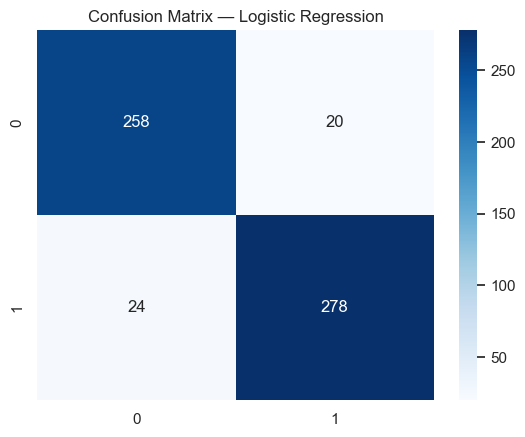

In [9]:
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
log_pred = log_model.predict(x_test)
log_acc = accuracy_score(y_test, log_pred)
log_acc

cm = confusion_matrix(y_test, log_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

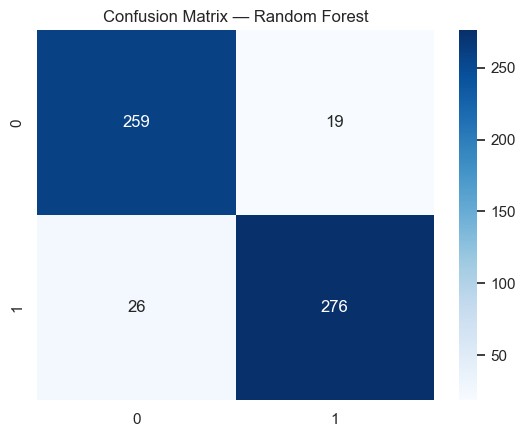

In [10]:
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(x_train, y_train)
rfc_pred = rfc_model.predict(x_test)
rfc_acc = accuracy_score(y_test, rfc_pred)
rfc_acc

cm1 = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm1, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix — Random Forest")
plt.show()

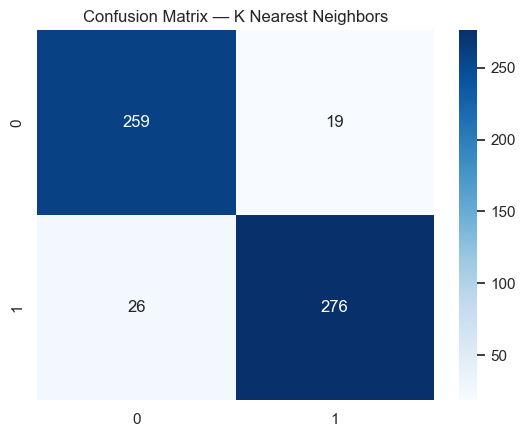

In [11]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
knn_pred = knn_model.predict(x_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
knn_acc

cm2 = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm1, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix — K Nearest Neighbors")
plt.show()

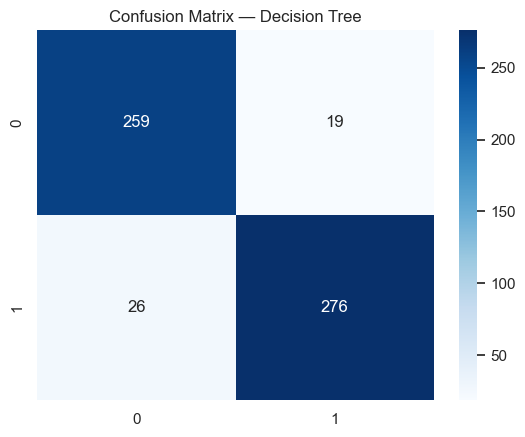

In [12]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=3)
tree_model.fit(x_train, y_train)
tree_pred = tree_model.predict(x_test)
tree_acc = accuracy_score(y_test, tree_pred)
tree_acc

cm3 = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm1, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix — Decision Tree")
plt.show()

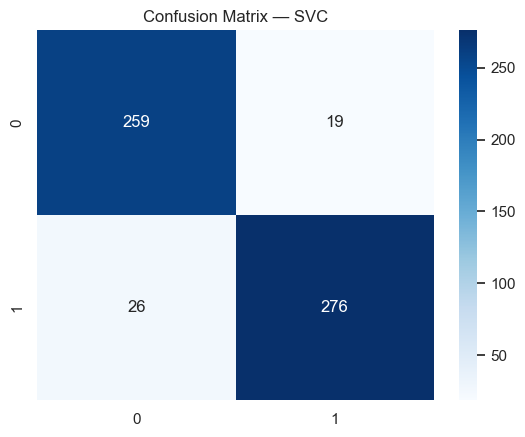

In [13]:
svc_model = SVC(kernel='poly', random_state=42)
svc_model.fit(x_train_scaled, y_train)
svc_pred = svc_model.predict(x_test_scaled)
svc_acc = accuracy_score(y_test, svc_pred)
svc_acc

cm4 = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm1, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix — SVC")
plt.show()

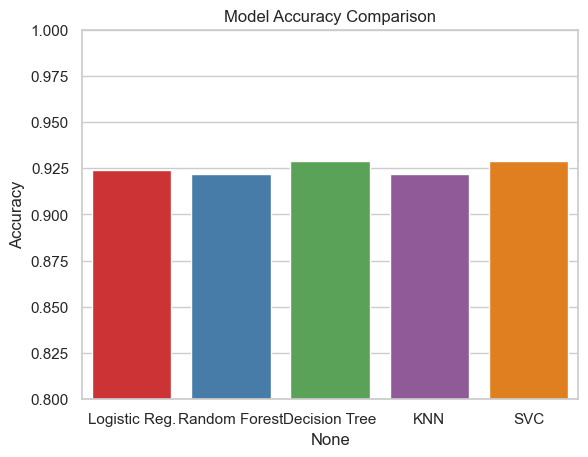

In [14]:
model_names = ['Logistic Reg.', 'Random Forest', 'Decision Tree', 'KNN', 'SVC']
accuracy_scores = pd.Series(
    [log_acc, rfc_acc, tree_acc, knn_acc, svc_acc],
    index=model_names
).round(3)

sns.barplot(x=accuracy_scores.index, y=accuracy_scores.values, palette='Set1', hue=accuracy_scores.index, legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

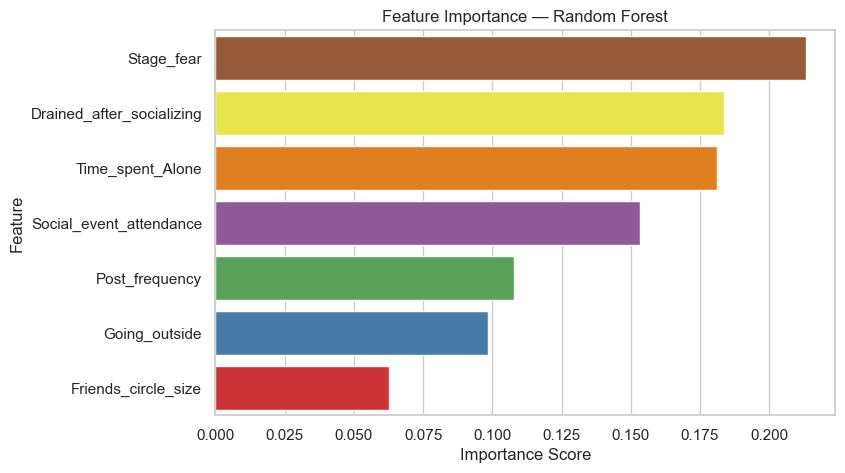

In [15]:
importances = rfc_model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Set1', hue=feat_importance.values, legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

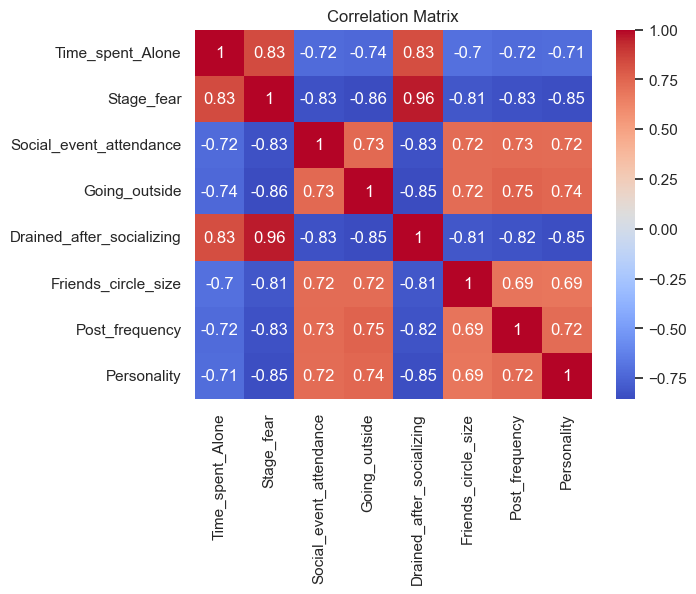

In [16]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

All trained models showed strong performance, with accuracy scores ranging from 0.92 to 0.93.
The Decision Tree achieved the highest accuracy (~0.93), followed closely by Logistic Regression, KNN, Random Forest, and SVC.

The small variability between models suggests that:
	•	The dataset is clean and well-separated
	•	Behavioral features strongly correlate with introversion/extroversion
	•	Even simple linear models can capture the relationships well

⸻

Key Behavioral Insights
	•	The highest predicted scores and strongest patterns were observed in traits such as:
	•	Stage fear
	•	Feeling drained after social interaction
	•	Need for time alone to recharge
	•	These traits strongly correlated with each other, suggesting they represent a consistent underlying personality dimension (possibly introversion, social energy sensitivity, or social anxiety tendencies).
	•	The confusion matrix showed that the model handled these categories well, often predicting them correctly even when the difference between classes was subtle.

⸻

Model Selection

While the Decision Tree slightly outperformed others, the best practical model for deployment would be:

 Random Forest Classifier

Because it provides:
	•	Better generalization
	•	Stability
	•	Lower risk of overfitting
	•	Feature importance scores (interpretability)